In [38]:
# # Task 3: Feature Engineering & Preprocessing Pipeline

# ## Customer Churn Dataset

# ### Objective

# Build a robust, reusable, and leak-free machine learning preprocessing pipeline using Scikit-Learn.

# ### Requirements

# 1. Load a tabular dataset
# 2. Perform train/test splitting before preprocessing
# 3. Handle missing values
# 4. Scale numerical features
# 5. Encode categorical features
# 6. Use ColumnTransformer
# 7. Use Scikit-Learn Pipeline
# 8. Perform correlation analysis
# 9. Perform feature importance analysis using Mutual Information

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif

## 1. Load Dataset

In [40]:
df = pd.read_csv("customer-churn-training.csv")

df.head()

,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


## 2. Dataset Overview

In [41]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.shape

Number of rows: 12
Number of columns: 7


(12, 7)

In [42]:
print("Column names:")
print(df.columns.tolist())

Column names:
['customer_id', 'tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type', 'churned']


In [43]:
df.dtypes

,0
customer_id,object
tenure_months,int64
support_tickets,int64
monthly_spend_inr,int64
last_login_days,int64
plan_type,object
churned,int64


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        12 non-null     object
 1   tenure_months      12 non-null     int64 
 2   support_tickets    12 non-null     int64 
 3   monthly_spend_inr  12 non-null     int64 
 4   last_login_days    12 non-null     int64 
 5   plan_type          12 non-null     object
 6   churned            12 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 804.0+ bytes


In [45]:
df.describe()

,tenure_months,support_tickets,monthly_spend_inr,last_login_days,churned
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,12.166667,2.250000,915.666667,10.000000,0.416667
std,9.242524,1.602555,332.574895,9.095453,0.514929
min,1.000000,0.000000,499.000000,1.000000,0.000000
25%,5.500000,1.000000,724.000000,2.750000,0.000000
50%,9.500000,2.000000,899.000000,7.000000,0.000000
75%,18.500000,3.250000,1074.000000,14.750000,1.000000
max,30.000000,5.000000,1499.000000,30.000000,1.000000


## 3. Missing Value Analysis

In [46]:
missing_values = df.isnull().sum()

print(missing_values)

customer_id          0
tenure_months        0
support_tickets      0
monthly_spend_inr    0
last_login_days      0
plan_type            0
churned              0
dtype: int64


In [47]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [48]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [49]:
print(
    "Duplicate customer IDs:",
    df["customer_id"].duplicated().sum()
)

Duplicate customer IDs: 0


## 4. Define Features and Target

The target variable is `churned`.

The `customer_id` column is excluded because it is an identifier rather than a meaningful predictive feature.

In [50]:
X = df.drop(columns=["churned", "customer_id"])
y = df["churned"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days', 'plan_type']

Target:
churned


In [51]:
print("Target distribution:")
print(y.value_counts())

Target distribution:
churned
0    7
1    5
Name: count, dtype: int64


In [52]:
print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)


Target percentage:
churned
0    58.333333
1    41.666667
Name: proportion, dtype: float64


## 5. Train/Test Split

The dataset is split into training and testing sets before fitting any preprocessing transformations.

This prevents information from the test set from being used when learning imputation values, scaling parameters, or categorical encodings.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 9
Testing samples: 3


## 6. Identify Numerical and Categorical Features

In [54]:
numeric_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

categorical_features = [
    "plan_type"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['tenure_months', 'support_tickets', 'monthly_spend_inr', 'last_login_days']

Categorical features:
['plan_type']


## 7. Numerical Preprocessing Pipeline

The numerical preprocessing pipeline performs:

1. Missing-value imputation using the median.
2. Standardization using StandardScaler.

In [55]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## 8. Categorical Preprocessing Pipeline

The categorical preprocessing pipeline performs:

1. Missing-value imputation using the most frequent category.
2. One-hot encoding.

In [56]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

## 9. ColumnTransformer

ColumnTransformer applies different preprocessing pipelines to numerical and categorical features.

In [57]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure_months', 'support_tickets',
                                  'monthly_spend_inr', 'last_login_days']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['plan_type'])])

## 10. Complete Reusable Scikit-Learn Pipeline

In [58]:
preprocessing_pipeline = Pipeline([
    ("preprocessor", preprocessor)
])

preprocessing_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure_months',
                                                   'support_tickets',
                                                   'monthly_spend_inr',
                                                   'last_login_days']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['plan_type'])]))])

## 11. Fit and Transform

The pipeline is fitted only on the training data.

The test data is transformed using the already-fitted preprocessing steps.

In [59]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

X_test_processed = preprocessing_pipeline.transform(X_test)

In [60]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print()

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (9, 5)
Processed training shape: (9, 7)

Original testing shape: (3, 5)
Processed testing shape: (3, 7)


In [61]:
feature_names = preprocessing_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Processed feature names:")
for feature in feature_names:
    print(feature)

Processed feature names:
num__tenure_months
num__support_tickets
num__monthly_spend_inr
num__last_login_days
cat__plan_type_Basic
cat__plan_type_Pro
cat__plan_type_Standard


## 12. Correlation Analysis

Correlation analysis is performed on the numerical training features.

The correlation coefficient measures the strength and direction of a linear relationship between two numerical variables.

Correlation does not imply causation.

In [62]:
correlation_matrix = X_train[numeric_features].corr()

correlation_matrix

,tenure_months,support_tickets,monthly_spend_inr,last_login_days
tenure_months,1.000000,-0.929997,0.914543,-0.865168
support_tickets,-0.929997,1.000000,-0.843299,0.940636
monthly_spend_inr,0.914543,-0.843299,1.000000,-0.897597
last_login_days,-0.865168,0.940636,-0.897597,1.000000


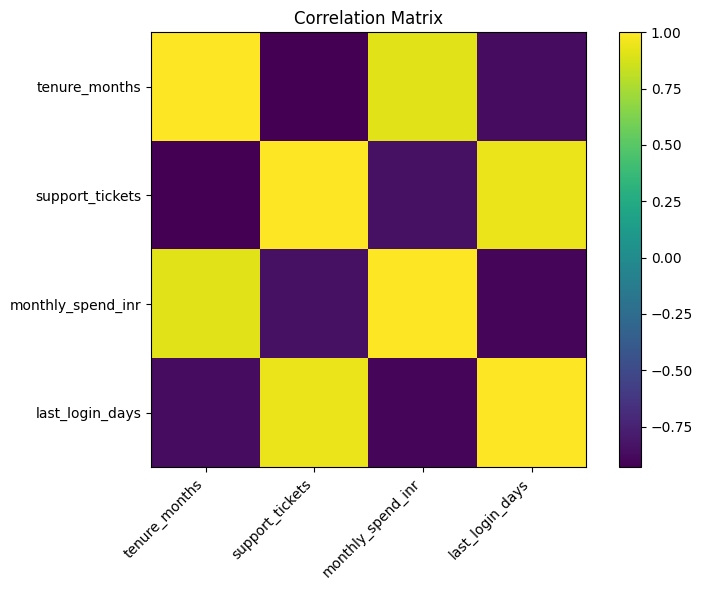

In [63]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 13. Feature Importance Using Mutual Information

Mutual information is used to estimate the dependency between each processed feature and the target variable.

Higher mutual-information values indicate stronger statistical dependency between the feature and the target in this dataset.

These values should not be interpreted as causal relationships.

In [64]:
X_train_array = X_train_processed

print("Processed training array shape:", X_train_array.shape)

Processed training array shape: (9, 7)


In [65]:
mi_scores = mutual_info_classif(
    X_train_array,
    y_train,
    random_state=42
)

print(mi_scores)

[0.64378307 0.46970899 0.46415344 0.58716931 1.41230159 0.01415344
 0.09563492]


In [66]:
mi_results = pd.DataFrame({
    "feature": feature_names,
    "mutual_information": mi_scores
})

mi_results = mi_results.sort_values(
    by="mutual_information",
    ascending=False
)

mi_results

,feature,mutual_information
4,cat__plan_type_Basic,1.412302
0,num__tenure_months,0.643783
3,num__last_login_days,0.587169
1,num__support_tickets,0.469709
2,num__monthly_spend_inr,0.464153
6,cat__plan_type_Standard,0.095635
5,cat__plan_type_Pro,0.014153


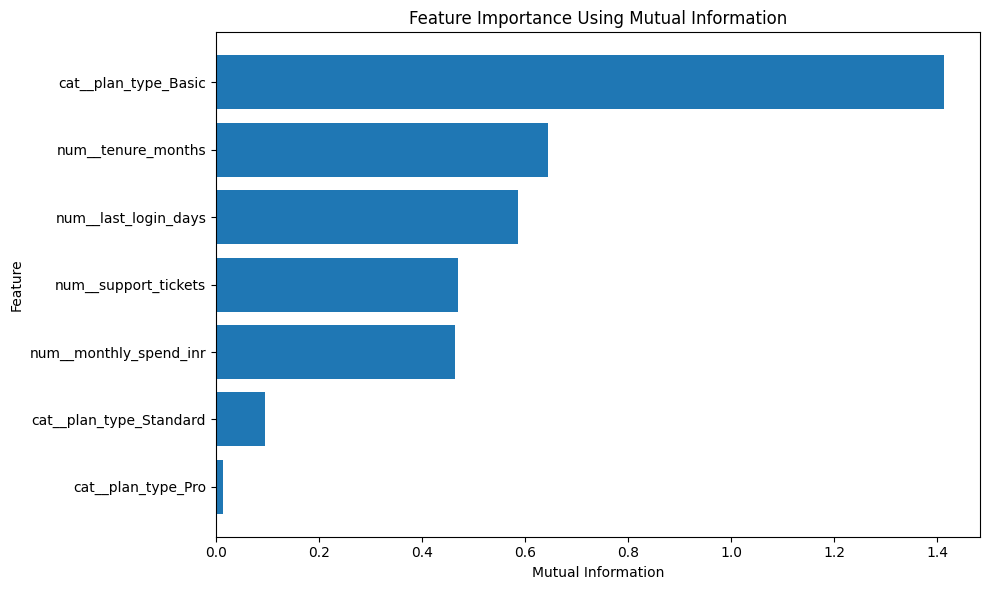

In [67]:
top_features = mi_results.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["mutual_information"]
)

plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Feature Importance Using Mutual Information")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 14. Pipeline Verification

The following requirements have been implemented:

- [x] Dataset loaded
- [x] Data inspected
- [x] Missing values checked
- [x] Duplicate records checked
- [x] Target identified
- [x] Customer identifier excluded
- [x] Train/test split performed before preprocessing
- [x] Numerical missing-value imputation
- [x] Numerical feature scaling
- [x] Categorical missing-value imputation
- [x] One-hot encoding
- [x] ColumnTransformer
- [x] Reusable Scikit-Learn Pipeline
- [x] Correlation analysis
- [x] Mutual information feature importance
- [x] Test data transformed without fitting preprocessing

## 15. Conclusion

A reusable and leak-free Scikit-Learn preprocessing pipeline was successfully implemented for the customer churn dataset.

The pipeline separates numerical and categorical features and applies appropriate preprocessing to each feature type.

Numerical features are processed using median imputation followed by StandardScaler. Categorical features are processed using most-frequent imputation followed by OneHotEncoder.

ColumnTransformer combines the two preprocessing pipelines, while the Scikit-Learn Pipeline provides a reusable preprocessing workflow.

The train/test split was performed before fitting the preprocessing pipeline. Therefore, preprocessing parameters are learned only from the training data and then applied to the test data, reducing the risk of data leakage.

Correlation analysis was performed on numerical training features, and Mutual Information was used to rank the processed features according to their statistical dependency with the churn target.

Because the provided dataset is very small, the feature-importance results should be considered educational and exploratory rather than production-level evidence.